In [1]:
#Conectar a Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls -la /content/drive/MyDrive/Riesgos/

total 2892
-rw------- 1 root root    1590 Mar 13 16:00 label_encoders.joblib
-rw------- 1 root root    1543 Mar 13 16:01 minmax_scaler.joblib
-rw------- 1 root root   69235 Mar 13 16:02 modelo_credito.keras
-rw------- 1 root root    2327 Mar 13 16:01 pca_model.joblib
-rw------- 1 root root 2884397 Mar 12 02:55 riesgo.xlsx


In [3]:
%cd /content/drive/MyDrive/Riesgos/

/content/drive/MyDrive/Riesgos


In [4]:
#Leer el archivo Excel riesgo.xlsx que se encuentra en la carpeta de Google Drive
import pandas as pd
df = pd.read_excel('riesgo.xlsx')
df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,CUS_0x1011,Schneyerh,43.875,793-05-8223,Doctor,58918.47,5208.872500,3.0,3.0,17,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,CUS_0x1013,Cameront,43.750,930-49-9615,Mechanic,98620.98,7962.415000,3.0,3.0,6,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


In [5]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               12500 non-null  object 
 1   Name                      12500 non-null  object 
 2   Age                       12500 non-null  float64
 3   SSN                       12500 non-null  object 
 4   Occupation                12500 non-null  object 
 5   Annual_Income             12500 non-null  float64
 6   Monthly_Inhand_Salary     12500 non-null  float64
 7   Num_Bank_Accounts         12500 non-null  float64
 8   Num_Credit_Card           12500 non-null  float64
 9   Interest_Rate             12500 non-null  int64  
 10  Num_of_Loan               12500 non-null  int64  
 11  Type_of_Loan              11074 non-null  object 
 12  Delay_from_due_date       12500 non-null  float64
 13  Num_of_Delayed_Payment    12500 non-null  float64
 14  Change

In [7]:
#Eliminar columnas irrelevantes Customer_ID, Name, SSN, Type_of_Loan
df.drop(columns=['Customer_ID', 'Name', 'SSN', 'Type_of_Loan'], axis=1, inplace=True)

#Eliminar valores nulos
df = df.dropna()

df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,Lawyer,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750,Mechanic,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500,Media_Manager,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875,Doctor,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,43.750,Mechanic,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,12500.0,33.311294,10.760177,14.000000,24.415179,33.000000,41.750000,56.000000
Annual_Income,12500.0,50505.123449,38300.762656,7005.930000,19342.972500,36999.705000,71683.470000,179987.280000
Monthly_Inhand_Salary,12500.0,4198.468568,3187.142979,303.645417,1625.744479,3097.016667,5961.664375,15204.633333
Num_Bank_Accounts,12500.0,5.368828,2.592493,0.000000,3.000000,5.375000,7.000000,10.500000
Num_Credit_Card,12500.0,5.533620,2.066040,0.500000,4.000000,5.000000,7.000000,10.875000
Interest_Rate,12500.0,14.532080,8.741636,1.000000,7.000000,13.000000,20.000000,34.000000
Num_of_Loan,12500.0,3.532880,2.446442,0.000000,2.000000,3.000000,5.000000,9.000000
Delay_from_due_date,12500.0,21.068780,14.772965,-2.000000,9.875000,17.875000,28.000000,63.250000
Num_of_Delayed_Payment,12500.0,13.338642,6.153148,0.000000,9.000000,13.750000,18.175000,26.375000
Changed_Credit_Limit,12500.0,10.465068,6.445141,0.500000,5.493750,9.370000,14.656250,31.115000


In [9]:
df.describe(include='object').T

,count,unique,top,freq
Occupation,12500,15,Lawyer,887
Credit_Mix,12500,3,Standard,5731
Payment_of_Min_Amount,12500,3,Yes,7360
Payment_Behaviour,12500,6,Low_spent_Small_value_payments,3860


In [10]:
df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       12500 non-null  float64
 1   Occupation                12500 non-null  object 
 2   Annual_Income             12500 non-null  float64
 3   Monthly_Inhand_Salary     12500 non-null  float64
 4   Num_Bank_Accounts         12500 non-null  float64
 5   Num_Credit_Card           12500 non-null  float64
 6   Interest_Rate             12500 non-null  int64  
 7   Num_of_Loan               12500 non-null  int64  
 8   Delay_from_due_date       12500 non-null  float64
 9   Num_of_Delayed_Payment    12500 non-null  float64
 10  Changed_Credit_Limit      12500 non-null  float64
 11  Num_Credit_Inquiries      12500 non-null  float64
 12  Credit_Mix                12500 non-null  object 
 13  Outstanding_Debt          12500 non-null  float64
 14  Credit

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,Lawyer,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750,Mechanic,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500,Media_Manager,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875,Doctor,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,43.750,Mechanic,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


In [11]:
#Separar columnas por tipo de dato (objetos y numéricos)
object_cols = df.select_dtypes(include='object').columns
numeric_cols = df.select_dtypes(include='number').columns

print('Columnas de tipo objeto:', object_cols)
print('Columnas de tipo numérico:', numeric_cols)

Columnas de tipo objeto: Index(['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object')
Columnas de tipo numérico: Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance', 'Credit_Score'],
      dtype='object')


In [12]:
#Recorrer columnas object e imprimir la cardinalidad usando unique
for col in object_cols:
    print(f'Columna: {col}, Cardinalidad: {df[col].nunique()}')

Columna: Occupation, Cardinalidad: 15
Columna: Credit_Mix, Cardinalidad: 3
Columna: Payment_of_Min_Amount, Cardinalidad: 3
Columna: Payment_Behaviour, Cardinalidad: 6


In [13]:
#Importar LabelEncoder de sklearn para codificar variables categóricas
from sklearn.preprocessing import LabelEncoder

#Copia del DataFrame original
df_limpio = df.copy()

#Aplicar LabelEncoder a las columnas de tipo objeto
label_encoders = {}
for col in object_cols:
    le = LabelEncoder()
    df_limpio[col] = le.fit_transform(df_limpio[col])
    label_encoders[col] = le

#Verificar que no hayan columnas de tipo objeto
print("Columnas de tipo objeto en el DataFrame limpio:", df_limpio.select_dtypes(include='object').columns.tolist())
df_limpio.head()

Columnas de tipo objeto en el DataFrame limpio: []


,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,7,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,...,0,1562.91,33.477546,10.458333,2,42.941090,158.549735,1,335.375341,0
1,25.750,9,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,...,2,202.68,29.839984,30.714286,2,108.366467,146.679378,1,428.743155,1
2,18.500,10,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,...,1,1030.20,34.841449,15.571429,1,0.000000,505.386526,0,781.229776,0
3,43.875,3,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,...,2,473.14,27.655897,15.541667,2,123.434939,311.060914,4,332.642837,1
4,43.750,9,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,...,1,1233.51,31.933940,17.535714,1,228.018084,355.442408,1,472.781009,1


In [14]:
df_limpio.shape

(12500, 22)

In [15]:
#Importar joblib para guardar el DataFrame limpio
import joblib

#Guardar todos los LabelEncoder en un solo archivo
joblib.dump(label_encoders, 'label_encoders.joblib')

print("LabelEncoders guardados correctamente.")

LabelEncoders guardados correctamente.


In [16]:
#Importat SelectKBest y f_classif para la selección de características
from sklearn.feature_selection import SelectKBest, f_classif

#Definir variables para clasificación multiclase (y en {0, 1, 2})
X = df_limpio.drop(columns=['Credit_Score'])
y = df_limpio['Credit_Score']

#SelectKBest con k = 10
selector = SelectKBest(score_func=f_classif, k=10)
X_kbest_array = selector.fit_transform(X, y)

#Nombres de las features seleccionadas
selected_features = X.columns[selector.get_support()].to_list()
print("Features seleccionadas:", selected_features)

#DataFrame con las features seleccionadas
X_kbest = pd.DataFrame(X_kbest_array, columns=selected_features, index=X.index)
X_kbest.head()

Features seleccionadas: ['Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount']


,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount
0,6.0,5.0,27.0,62.25,25.000000,10.875000,0.0,1562.91,10.458333,2.0
1,6.0,5.0,17.0,7.25,17.857143,3.000000,2.0,202.68,30.714286,2.0
2,1.0,4.0,1.0,13.50,7.375000,1.857143,1.0,1030.20,15.571429,1.0
3,3.0,3.0,17.0,27.25,14.500000,7.000000,2.0,473.14,15.541667,2.0
4,3.0,3.0,6.0,12.50,8.428571,3.000000,1.0,1233.51,17.535714,1.0


In [17]:
#Mapa de todas las columnas: inglés - español
mapa_columnas = {
    "Age": "Edad",
    "Annual_Income": "Ingreso_Anual",
    "Monthly_Inhand_Salary": "Salario_Mensual_Neto",
    "Num_Bank_Accounts": "Num_Cuentas_Bancarias",
    "Num_Credit_Card": "Num_Tarjetas_Credito",
    "Interest_Rate": "Tasa_Interes",
    "Num_of_Loan": "Num_Prestamos",
    "Delay_from_due_date": "Retraso_Desde_Vencimiento",
    "Num_of_Delayed_Payment": "Num_Pagos_Retrasados",
    "Changed_Credit_Limit": "Cambio_Limite_Credito",
    "Num_Credit_Inquiries": "Num_Consultas_Credito",
    "Credit_Mix": "Mezcla_Credito",
    "Outstanding_Debt": "Deuda_Pendiente",
    "Credit_Utilization_Ratio": "Ratio_Utilizacion_Credito",
    "Credit_History_Age": "Antiguedad_Historial_Crediticio",
    "Payment_of_Min_Amount": "Pago_Monto_Minimo",
    "Total_EMI_per_month": "Cuota_Mensual_Total",
    "Amount_invested_monthly": "Monto_Invertido_Mensual",
    "Payment_Behaviour": "Comportamiento_Pago",
    "Monthly_Balance": "Balance_Mensual",
    "Credit_Score": "Puntaje_Credito",
}

#Renombrar columnas en los DataFrames existentes
df.rename(columns=mapa_columnas, inplace=True)
df_limpio.rename(columns=mapa_columnas, inplace=True)
X.rename(columns=mapa_columnas, inplace=True)
X_kbest.rename(columns=mapa_columnas, inplace=True)

#Actualizar lista de features seleccionadas con los nuevos nombres
selected_features = [mapa_columnas.get(feat, feat) for feat in selected_features]

#Verificar los cambios
print(X_kbest.columns.tolist())

['Num_Cuentas_Bancarias', 'Num_Tarjetas_Credito', 'Tasa_Interes', 'Retraso_Desde_Vencimiento', 'Num_Pagos_Retrasados', 'Num_Consultas_Credito', 'Mezcla_Credito', 'Deuda_Pendiente', 'Antiguedad_Historial_Crediticio', 'Pago_Monto_Minimo']


In [18]:
#Importar MinMaxScaler para normalizar las features numéricas
from sklearn.preprocessing import MinMaxScaler

#Normalizar las features numéricas en X_kbest
scaler = MinMaxScaler()
X_kbest_scaled_array = scaler.fit_transform(X_kbest)

#Convertir a DataFrame conservando columnas e índice
X_kbest_norm = pd.DataFrame(X_kbest_scaled_array, columns=X_kbest.columns, index=X_kbest.index)

#Persistir el modelo de normalización
joblib.dump(scaler, "minmax_scaler.joblib")
print("MinMaxScaler guardado correctamente.")
X_kbest_norm.head()

MinMaxScaler guardado correctamente.


,Num_Cuentas_Bancarias,Num_Tarjetas_Credito,Tasa_Interes,Retraso_Desde_Vencimiento,Num_Pagos_Retrasados,Num_Consultas_Credito,Mezcla_Credito,Deuda_Pendiente,Antiguedad_Historial_Crediticio,Pago_Monto_Minimo
0,0.571429,0.433735,0.787879,0.984674,0.947867,0.664122,0.0,0.312671,0.305500,1.0
1,0.571429,0.433735,0.484848,0.141762,0.677048,0.183206,1.0,0.040507,0.919206,1.0
2,0.095238,0.337349,0.000000,0.237548,0.279621,0.113413,0.5,0.206083,0.460415,0.5
3,0.285714,0.240964,0.484848,0.448276,0.549763,0.427481,1.0,0.094623,0.459513,1.0
4,0.285714,0.240964,0.151515,0.222222,0.319567,0.183206,0.5,0.246763,0.519928,0.5


In [19]:
#Importar PCA para reducción de dimensionalidad
from sklearn.decomposition import PCA

#Aplicar PCA con 8 componentes sobre el DataFrame normalizado
pca = PCA(n_components=8)
X_pca = pca.fit_transform(X_kbest_norm)

#Convertir a DataFrame con nombres de componentes
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns, index=X_kbest_norm.index)
X_pca_df.head()

#Crear DataFrame con los pesos (loadings) de cada componente
loadings = pd.DataFrame(pca.components_.T, columns=pca_columns, index=X_kbest_norm.columns)

#Guardar el modelo PCA
joblib.dump(pca, "pca_model.joblib")
print("Modelo PCA guardado correctamente.")

print(f"\nVarianza explicada por cada componente: {pca.explained_variance_ratio_}")
print(f"Varianza total explicada por las 8 componentes: {pca.explained_variance_ratio_.sum():.4f}")
print("\nLoadings (pesos) de cada componente:")
print(loadings)

Modelo PCA guardado correctamente.

Varianza explicada por cada componente: [0.52079978 0.19932726 0.05616517 0.04079909 0.03594418 0.0345975
 0.03244441 0.03108677]
Varianza total explicada por las 8 componentes: 0.9512

Loadings (pesos) de cada componente:
                                      PC1       PC2       PC3       PC4  \
Num_Cuentas_Bancarias           -0.296483  0.213420  0.510049 -0.340539   
Num_Tarjetas_Credito            -0.212739  0.033820  0.131030  0.488724   
Tasa_Interes                    -0.360354  0.179851 -0.008732  0.573115   
Retraso_Desde_Vencimiento       -0.292084  0.044083  0.284817  0.142301   
Num_Pagos_Retrasados            -0.281388  0.182561  0.381048 -0.351250   
Num_Consultas_Credito           -0.304005  0.125116 -0.256760  0.110613   
Mezcla_Credito                   0.436201  0.833343 -0.034742  0.102230   
Deuda_Pendiente                 -0.326939 -0.069420 -0.170297  0.027828   
Antiguedad_Historial_Crediticio  0.321488 -0.113817  0.602991  0.3

In [20]:
#Importar To_Categorical para convertir la variable objetivo a categórica
from tensorflow.keras.utils import to_categorical
import numpy as np

#Mostrar y original
print("y original (primeras 10 valores):")
print(y.values[:10])
print(f"\nValores únicos en y:", np.unique(y))
print(f"Shape original: {y.shape}")

#Convertir y a One-Hot Encoding
y_categorical = to_categorical(y)
print("\ny transformada con to_categorical (primeros 10 valores):")
print(y_categorical[:10])
print(f"Shape transformada: {y_categorical.shape}")
print(f"Número de clases: {y_categorical.shape[1]}")

y original (primeras 10 valores):
[0 1 0 1 1 2 0 1 2 1]

Valores únicos en y: [0 1 2]
Shape original: (12500,)

y transformada con to_categorical (primeros 10 valores):
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]
Shape transformada: (12500, 3)
Número de clases: 3


In [21]:
#Importar train_test_split de sklearn para dividir el dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split

#Dividir los datos en entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_pca_df, y_categorical, test_size=0.2, random_state=42, stratify=y)

print(f"Conjunto de entrenamiento: X_train shape = {X_train.shape}, y_train shape = {y_train.shape}")
print(f"Conjunto de prueba: X_test shape = {X_test.shape}, y_test shape = {y_test.shape}")

Conjunto de entrenamiento: X_train shape = (10000, 8), y_train shape = (10000, 3)
Conjunto de prueba: X_test shape = (2500, 8), y_test shape = (2500, 3)


In [22]:
#Importar Sequential, Dense, Input y Adam de Keras para construir la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

#Crear el modelo secuencial
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

#Compilar el modelo con Adam y categorical_crossentropy
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,235 (12.64 KB)

 Trainable params: 3,235 (12.64 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#Crear EarlyStopping para evitar sobreajuste
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [24]:
#Entrenar el modelo con validación y EarlyStopping
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, callbacks=[early_stopping])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6942 - loss: 0.7285 - val_accuracy: 0.7292 - val_loss: 0.6557
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7353 - loss: 0.6379 - val_accuracy: 0.7344 - val_loss: 0.6327
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7382 - loss: 0.6220 - val_accuracy: 0.7388 - val_loss: 0.6306
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7367 - loss: 0.6167 - val_accuracy: 0.7412 - val_loss: 0.6229
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7394 - loss: 0.6114 - val_accuracy: 0.7460 - val_loss: 0.6203
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7398 - loss: 0.6094 - val_accuracy: 0.7440 - val_loss: 0.6208
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7419 - loss: 0.6057 - val_accuracy: 0.7416 - val_loss: 0.6218
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7418 - loss: 0.6046 - val_acc

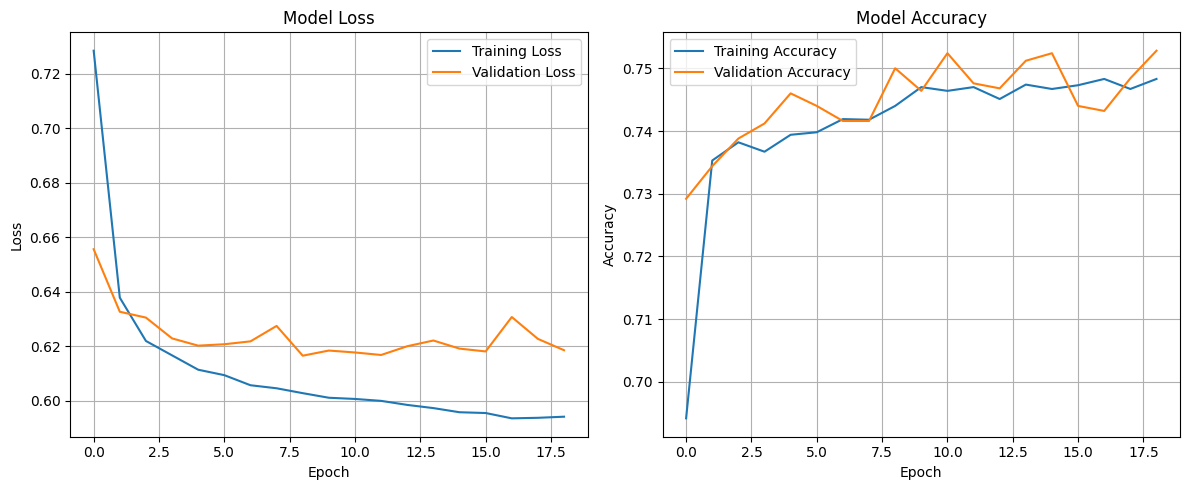

Última pérdida de entrenamiento: 0.5942
Última pérdida de validación: 0.6186
Última precisión de entrenamiento: 0.7483
Última precisión de validación: 0.7528


In [25]:
import matplotlib.pyplot as plt

#Graficar la pérdida (loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

#Graficar la precisión (accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

#Mostrar los valores finales
print(f"Última pérdida de entrenamiento: {history.history['loss'][-1]:.4f}")
print(f"Última pérdida de validación: {history.history['val_loss'][-1]:.4f}")
print(f"Última precisión de entrenamiento: {history.history['accuracy'][-1]:.4f}")
print(f"Última precisión de validación: {history.history['val_accuracy'][-1]:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


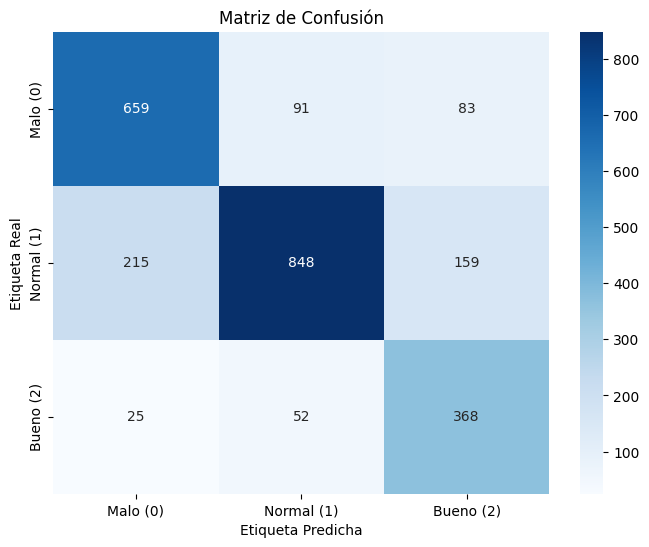

Reporte de Clasificación:
              precision    recall  f1-score   support

    Malo (0)       0.73      0.79      0.76       833
  Normal (1)       0.86      0.69      0.77      1222
   Bueno (2)       0.60      0.83      0.70       445

    accuracy                           0.75      2500
   macro avg       0.73      0.77      0.74      2500
weighted avg       0.77      0.75      0.75      2500



In [26]:
#Importar la matriz de confusión y clasificación report de sklearn
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

#Predecir clases para el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

#Crear la matriz de confusión
cm = confusion_matrix(y_true_classes, y_pred_classes)

#Etiquetas de las clases
class_labels = ['Malo (0)', 'Normal (1)', 'Bueno (2)']

#Visualizar la matriz de confusión con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión')
plt.show()

#Mostrar estadísticas del modelo
print("Reporte de Clasificación:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels))

In [27]:
#Guardar el modelo en formato keras
model.save("modelo_credito.keras")
print("Modelo guardado correctamente.")

Modelo guardado correctamente.
